# 안녕하세요^^ 
# AIVLE 미니 프로젝트에 오신 여러분을 환영합니다.
* 본 과정에서는 실제 사례와 데이터를 기반으로 문제를 해결하는 전체 과정을 자기 주도형 실습으로 진행해볼 예정입니다.
* 앞선 교육과정을 정리하는 마음과 지금까지 배운 내용을 바탕으로 문제 해결을 해볼게요!
* 미니 프로젝트를 통한 문제 해결 과정 'A에서 Z까지', 지금부터 시작합니다!

----

# __[Study] 1. Roboflow 이미지 데이터셋 활용 YOLOv5 ObjectDetection__
- Roboflow란? <br>
Roboflow는 컴퓨터 비전(Computer Vision) 기술을 이용해 다양한 애플리케이션을 만들 수 있도록 지원해주는 서비스입니다. <br> 
Roboflow는 다양한 무료 데이터셋을 지원하고 있다는 특징이 있는데요, 사이트에 접속한 뒤에 다양한 무료 데이터셋을 다운로드할 수 있습니다.

## 0. 환경 설정하기

### 1) 구글 드라이브 연결하기


In [1]:
# 코랩 사용 시 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2) 경로 확인하기
- "WORK_SPACE" 에 본인 작업 경로 작성 후 실행(구글 드라이브 최상위에 압축해제 시 그대로 실행. 수정 X).<br>

In [30]:
import os

In [2]:
# ROOT_PATH 확인 
import os

WORK_SPACE = "/content/drive/MyDrive/Colab Notebooks/aivle/6차미니프로젝트"

if os.getcwd() == '/content' :
  # 구글 드라이브 사용 시 
  ROOT_PATH = "/content/drive/MyDrive" + WORK_SPACE 
else :
  ROOT_PATH = os.path.abspath('..')

### 1) YOLOv5파일 다운로드 및 설치

![install](https://github.com/DrKAI/CV/raw/main/UltraLytics_manual/yolov5_install.png)

[Install Page](https://github.com/ultralytics/yolov5)



In [3]:
# UltraLytics git에서 복사하기
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 14411, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 14411 (delta 12), reused 22 (delta 10), pack-reused 14379
Receiving objects: 100% (14411/14411), 13.37 MiB | 5.57 MiB/s, done.
Resolving deltas: 100% (9962/9962), done.


In [4]:
# 현재 작업 디렉토리 확인하기
%pwd

'/content'

In [5]:
# yolov5 폴더 이동 및 requirements.txt 내부 패키지 설치
%cd yolov5
!pip install -r requirements.txt

/content/yolov5
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 1.6 MB 37.4 MB/s 


---

## 1. 데이터 불러오기
* roboflow 사이트 접속하여 Public 데이터셋 받아오기
> https://universe.roboflow.com/<br>
> ① roboflow 라이브러리 설치
```# 코드로 형식 지정됨
!pip install roboflow
```
> ② roboflow 데이터셋 다운로드<br>
> [방법1] - 다운로드 위치 "/content/Hard-Hat-Workers-2"
```# 코드로 형식 지정됨
from roboflow import Roboflow
rf = Roboflow(api_key="APIkey입력")
project = rf.workspace().project("프로젝트명입력")
dataset = project.version(버전입력).download("yolov5")
```
> [방법2] - 다운로드 위치 "/content"
```# 코드로 형식 지정됨
!curl -L "https://universe.roboflow.com/ds/wVehfWuh5r?key=lLfUBqgdca" > roboflow.zip; unzip roboflow.zip; rm roboflow.zip
```



<font color="green">[실습문제]</font> 1. roboflow 사이트에 접속하여 "Hard Hat Workers Dataset >> raw_75-25_trainTestSplit" 데이터셋을 다운로드하세요.

In [6]:
# 현재 작업 경로 확인하기
%pwd

'/content/yolov5'

In [7]:
%cd ..

/content


In [9]:
# 실습해보세요 - [방법1]
!pip install roboflow

from roboflow import Roboflow

# rf = Roboflow(api_key="F9qPFlGFakchWwhZnwzZ")
# project = rf.workspace("mosquito").project("mosquito-0clhq")
# dataset = project.version(6).download("yolov5")

rf = Roboflow(api_key="F9qPFlGFakchWwhZnwzZ")
project = rf.workspace("venkat-mukthineni").project("mosquito-detection-fqch7")
dataset = project.version(10).download("yolov5")

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 145 kB 57.2 MB/s 
     |████████████████████████████████| 178 kB 65.2 MB/s 
     |████████████████████████████████| 67 kB 6.3 MB/s 
     |████████████████████████████████| 54 kB 3.4 MB/s 
     |████████████████████████████████| 138 kB 70.6 MB/s 
     |████████████████████████████████| 62 kB 1.6 MB/s 
  Created wheel for roboflow: filename=roboflow-0.2.17-py3-none-any.whl size=31935 sha256=f49c8b50875960573ae474b61c4d80ea73b8347376ec752f7dc7d6004e8fd065
  Stored in directory: /root/.cache/pip/wheels/f2/38/3c/b4ac4d8a9d9b44bdcd51f6148ec810b0f05a404e5fed8df48d
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9675 sha256=998949f82fced012370b84ec189d27e3932e7f91c48c307883681bca598a972a
  Stored in directory: /root/.cache/pip/wheels/a1/b6/7c/0e63e34eb06634181c63adacca38b79ff8f35c37e3c13e3c02
Successfully built roboflow wget
  Attempting u

loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to Mosquito-Detection-10 in yolov5pytorch:: 100%|██████████| 6676/6676 [00:01<00:00, 3347.66it/s]


In [ ]:
# 실습해보세요 - [방법2]
#!curl -L "https://universe.roboflow.com/ds/wVehfWuh5r?key=lLfUBqgdca" > roboflow.zip; unzip roboflow.zip; rm roboflow.zip

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
 extracting: train/labels/002296_jpg.rf.0c9e2f0756e58251ba576c4799a52013.txt  
 extracting: train/labels/000135_jpg.rf.0ca2fda801cbc26acad48a4970d5fd9c.txt  
 extracting: train/labels/000927_jpg.rf.0c8662a3294885b1dce0b9c9f71bf63d.txt  
 extracting: train/labels/003070_jpg.rf.0d4f1aa374695130ec80a94eb7d3029f.txt  
 extracting: train/labels/004879_jpg.rf.0d5c27700ff04fb911be2cc0b0ae7e44.txt  
 extracting: train/labels/000307_jpg.rf.0da33908e280d7c9d61d7cb6470ecd3f.txt  
 extracting: train/labels/005099_jpg.rf.0de8be5e21e09352a246b6c1faf53ecc.txt  
 extracting: train/labels/004482_jpg.rf.0d541b29bd4b4ededc19b5cafebb4fe9.txt  
 extracting: train/labels/000735_jpg.rf.0d5b96188e544511c13ac1e1bfff0b87.txt  
 extracting: train/labels/001653_jpg.rf.0cc3a72fd244aa7aadee6c4d766190df.txt  
 extracting: train/labels/002922_jpg.rf.0d24f020d6f688f966ef38c7a0eeba3e.txt  
 extracting: train/labels/004334_jpg.rf.0c7c46e2c74725ad2f93e916dc2422dd.txt  
 extracting: tra

## 2. 모델링을 위한 Train Data(학습)와 Test 데이터(검증) 확인
* 폴더 구조를 불러올 때 쓰는 glob 라이브러리 활용
* 다운로드 받은 데이터의 경로를 미리 변수로 설정해서 지정해 두시면 편리합니다.
> [방법1] 
>> DATA_PATH = "/content/Hard-Hat-Workers-2" <br>
>> TRAIN_PATH = "/content/Hard-Hat-Workers-2/train"<br>
>> VALIDATION_PATH = "/content/Hard-Hat-Workers-2/test"<br>
>>
> [방법2] <br>
>> DATA_PATH = "/content"<br>
>> TRAIN_PATH = "/content/train"<br> 
>> VALIDATION_PATH = "/content/test" <br>  

<font color="green">[실습문제]</font> 2. Train Data와 Test Data 이미지 개수를 확인하세요.

In [6]:
# 필요 라이브러리 불러오기
import glob

In [7]:
# 실습해보세요
# DATA_PATH 지정하기
DATA_PATH = "/content/Mosquito-Detection-10/"
TRAIN_PATH = "/content/Mosquito-Detection-10/train"
VALIDATION_PATH = "/content/Mosquito-Detection-10/test"

train_image_list = glob.glob(TRAIN_PATH + "/images/*.jpg")
validation_image_list = glob.glob(VALIDATION_PATH + "/images/*.jpg")

In [8]:
print("학습 데이터(이미지) 개수 : " + str(len(train_image_list)))
print("검증 데이터(이미지) 개수 : " + str(len(validation_image_list)))

학습 데이터(이미지) 개수 : 2913
검증 데이터(이미지) 개수 : 143


## 3. Yaml 파일 수정하기
* Yaml이란? xml과 json 포맷과 같이 타 시스템 간에 데이터를 주고받을 때 약속된 포맷(규칙)이 정의되어있는 파일 형식<br>
https://abluesnake.tistory.com/128<br>

<font color="green">[실습문제]</font> 3. data.yaml 파일의 정보를 확인해 보세요.
- Python의 PyYAML 라이브러리를 이용하여 Yaml 파일을 파싱하여 파이썬 객체로 읽어 오세요.
- yaml 파일은 파싱하여 Python 객체로 읽어올 때는 load() 메소드를 사용합니다.<br>
> [정보] ① names : class이름, ② nc : class종류 ③ train/validation 경로

In [10]:
# 필요 라이브러리 불러오기
import yaml

In [11]:
# 실습해보세요.
with open('/content/Mosquito-Detection-10/data.yaml', 'r') as f:
  data = yaml.load(f, Loader=yaml.FullLoader)

print(data)

{'names': ['mosquito'], 'nc': 1, 'train': '/content/Mosquito-Detection-10/train.txt', 'val': '/content/Mosquito-Detection-10/validation.txt'}


<font color="green">[실습문제]</font> 4. train, validation 이미지 경로를 txt 파일로 저장하기 
- yolov5 학습을 위해 data.yaml 파일 내 
train, val의 값을 이미지 파일들의 경로를 저장한 .txt 파일로 변경이 필요합니다.

In [12]:
# 실습해보세요
with open(DATA_PATH + '/train.txt', 'w') as f:
    f.write('\n'.join(train_image_list) + '\n')

with open(DATA_PATH + '/validation.txt', 'w') as f:
    f.write('\n'.join(validation_image_list) + '\n')

<font color="green">[실습문제]</font> 5. "data.yaml" 파일 내 train, validation 경로 .txt 파일 경로로 변경 후 저장

In [13]:
data['train'] = DATA_PATH + 'train.txt'
data['val'] = DATA_PATH + 'validation.txt'

with open(DATA_PATH + '/data.yaml', 'w') as f:
  yaml.dump(data, f)

print(data)

{'names': ['mosquito'], 'nc': 1, 'train': '/content/Mosquito-Detection-10/train.txt', 'val': '/content/Mosquito-Detection-10/validation.txt'}


## 4. Yolov5 를 이용한 모델 학습
> https://github.com/ultralytics/yolov5/wiki/Train-Custom-Data/<br>
> ○ [Command] 
```# 코드로 형식 지정됨
 !python train.py --img 640 --epochs 3 --data coco.yaml --weights yolov5n.pt --batch 128 
                                                                  yolov5s            64
                                                                  yolov5m            40
                                                                  yolov5l            24
                                                                  yolov5x            16
```

> ○ [Properties]
>> --img: 입력 이미지 크기 <br>
>> --batch: 배치 크기 <br>
>> --epochs: 학습 epoch 수 <br>
>> --data: data.yaml 파일 경로 <br>
>> --cfg: 모델 구성 지정 <br>
>> --weights: 가중치에 대한 사용자 정의 경로를 지정<br>
>> --name: 모델이 저장 될 폴더 이름 <br>
>> --nosave: 최종 체크포인트만 저장<br>
>> --cache: 더 빠른 학습을 위해 이미지를 캐시<br>

> ○ [Select Model]<br>
><img src="https://github.com/ultralytics/yolov5/releases/download/v1.0/model_comparison.png" width="640px">

<font color="green">[실습문제]</font> 6. Yolov5s(small) 모델을 활용하여 학습하세요.
> img size : 416 <br>
> batch size : 16 <br>
> epochs : 5 <br>
> data : /content/Hard-Hat-Workers-2/data.yaml <br>
> weights : yolov5s.pt <br>
> name : helmet_data_detection <br>

In [14]:
# 현재 경로 확인
%pwd

'/content'

In [15]:
# 실행 경로 이동
%cd yolov5

/content/yolov5


In [16]:
# 실습해보세요.
!python train.py --img 416 --batch 16 --epochs 5 --data /content/Mosquito-Detection-10/data.yaml --weights yolov5s.pt --name helmet_data_detection

train: weights=yolov5s.pt, cfg=, data=/content/Mosquito-Detection-10/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=5, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=helmet_data_detection, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v6.2-206-gfba61e5 Python-3.7.15 torch-1.12.1+cu113 CUDA:0 (Tesla T4, 15110MiB)

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, iou_t=0.2, anchor_t=4.0, fl_

## 5. 모델 성능 확인
> Yolo에서는 모델의 성능(정확도)를 Mean Average Precision(mAP)를 통해 확인합니다. <br>
mAP가 높을수록 정확하고, 작을수록 부정확합니다. <br>
> AP를 계산할 때, precision-recall, IoU 와 연관이 있습니다. <br>


<font color="green">[실습문제]</font> 7. model summary를 확인하여 Class 별, 전체 mAP를 확인해 보세요.

In [ ]:
# 실습해보세요.


```
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 56/56 [00:18<00:00,  3.05it/s]
                   all       1766       6808      0.963      0.608      0.646      0.403
                  head       1766       1803      0.942      0.896      0.944       0.59
                helmet       1766       4863      0.948      0.927      0.971      0.606
                person       1766        142          1          0     0.0243     0.0136
```



## 6. Test 데이터 추론하기 
* 해당 결과는 runs/detect/exp/ 위치에 저장됩니다.
> ○ [Command] 
``` # 코드로 형식 지정됨
!python detect.py --source 0  # webcam
                           img.jpg  # image
                           vid.mp4  # video
                           screen  # screenshot
                           path/  # directory
                           'path/*.jpg'  # glob
                           'https://youtu.be/Zgi9g1ksQHc'  # YouTube
                           'rtsp://example.com/media.mp4'  # RTSP, RTMP, HTTP stream
```
> ○ [Properties] 
>> -- source : test 데이터(이미지, 영상 파일 혹은 폴더) 경로 <br>
>> -- weights : 학습이 완료된 weight 파일 경로 (pt 형식) <br>
>> -- conf : conf_threshold 값 (0 ~ 1 사이의 값)


* TEST 데이터 다운로드하기(아래의 코드를 실행하세요)


In [17]:
# 현재 디렉토리 확인
%pwd
%cd /content

/content


In [2]:
!pip install gdown

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import gdown
import zipfile

In [ ]:
test_file_id = "14PsLrMhL2v7n3dYjv2JOFWF6iIUFYhyQ"

def goolge_drive_download (file_id): 
  google_path = 'https://drive.google.com/uc?id='
  output_name = 'download_file.zip'

  gdown.download(google_path+file_id,output_name,quiet=False)

  zip_file = "/content/download_file.zip"

  
  with zipfile.ZipFile(zip_file) as z:
    z.extractall("/content")

  os.remove(zip_file) 

In [ ]:
goolge_drive_download(test_file_id)

<font color="green">[실습문제]</font> 8-1. 이미지를 소스로 한 객체 검출하기 
> 아래의 코드를 실행하여 test_file을 다운로드 하고  "/content/test/images" 경로의 이미지 소스의 객체를 검출하세요<br>
> [조건] 
> ① img size : 416, ② IOU Threshold : 0.5, ③ 모델 weights : best.pt

In [33]:
# 경로 설정
TEST_IMAGE_PATH = "/content/test"

In [35]:
# 실습해보세요
!python detect.py --source '{TEST_IMAGE_PATH}' --weights /content/yolov5/runs/train/helmet_data_detection/weights/best.pt --img 416 --conf 0.5

detect: weights=['/content/yolov5/runs/train/helmet_data_detection/weights/best.pt'], source=/content/test, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v6.2-206-gfba61e5 Python-3.7.15 torch-1.12.1+cu113 CUDA:0 (Tesla T4, 15110MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
image 1/2 /content/test/MicrosoftTeams-image (1).png: 416x320 (no detections), 10.4ms
image 2/2 /content/test/MicrosoftTeams-image (2).png: 416x320 (no detections), 7.4ms
Speed: 0.4ms pre-process, 8.9ms inference, 0.3ms NMS per image at shape (1, 3, 416, 416)
Results saved to runs/detect/exp3


<font color="green">[실습문제]</font> 8-2. detect가 완료된 이미지를 확인해 보세요.

In [36]:
# 필요 라이브러리 불러오기
from PIL import Image               # to load images
from IPython.display import display # to display images

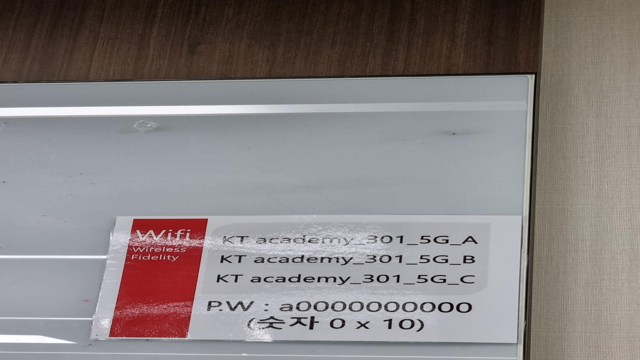

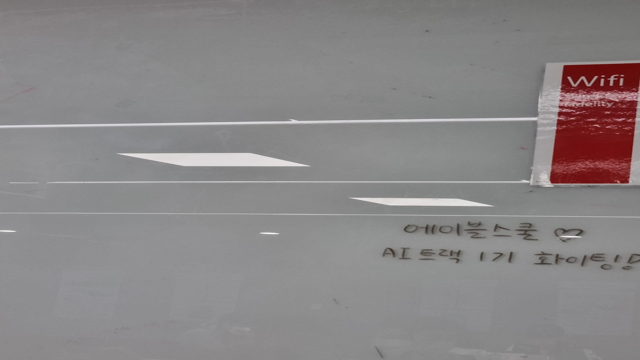

In [39]:
# 실습해보세요.
detect_image_path = "/content/yolov5/runs/detect/exp3"  #detect가 완료된 파일의 경로

for i in glob.glob(detect_image_path + '/*.png'):
  img = Image.open(i)
  img_resize = img.resize((640, 360))
  display(img_resize)
  print('\n')


<font color="green">[실습문제]</font> 9. 동영상을 소스로 한 객체 검출하기 
> 경로 "TEST_VIDEO_PATH" 의 이미지 파일들의 객체를 검출해 보세요.  
> [조건] 
> ① IOU Threshold : 0.5, ② 모델 weights : best.pt 

In [23]:
%pwd

'/content'

In [24]:
%cd yolov5

/content/yolov5


In [25]:
TEST_VIDEO_PATH="/content/drive/MyDrive/aivle/모기에게 박카스F를 줘봤습니다 잘먹긴 진짜 잘 먹습니다.mp4"

In [26]:
# 실습해보세요
!python detect.py --source '{TEST_VIDEO_PATH}' --weights /content/yolov5/runs/train/helmet_data_detection2/weights/best.pt --conf 0.5 --img 256

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
video 1/1 (6915/11912) /content/drive/MyDrive/aivle/모기에게 박카스F를 줘봤습니다 잘먹긴 진짜 잘 먹습니다.mp4: 160x256 (no detections), 8.3ms
video 1/1 (6916/11912) /content/drive/MyDrive/aivle/모기에게 박카스F를 줘봤습니다 잘먹긴 진짜 잘 먹습니다.mp4: 160x256 (no detections), 8.2ms
video 1/1 (6917/11912) /content/drive/MyDrive/aivle/모기에게 박카스F를 줘봤습니다 잘먹긴 진짜 잘 먹습니다.mp4: 160x256 (no detections), 15.4ms
video 1/1 (6918/11912) /content/drive/MyDrive/aivle/모기에게 박카스F를 줘봤습니다 잘먹긴 진짜 잘 먹습니다.mp4: 160x256 (no detections), 11.7ms
video 1/1 (6919/11912) /content/drive/MyDrive/aivle/모기에게 박카스F를 줘봤습니다 잘먹긴 진짜 잘 먹습니다.mp4: 160x256 (no detections), 8.5ms
video 1/1 (6920/11912) /content/drive/MyDrive/aivle/모기에게 박카스F를 줘봤습니다 잘먹긴 진짜 잘 먹습니다.mp4: 160x256 (no detections), 8.6ms
video 1/1 (6921/11912) /content/drive/MyDriv

<font color="green">[실습문제]</font> 9-2. detect가 완료된 동영상을 확인해 보세요.

In [27]:
# 실습해보세요.
detect_video = '/content/yolov5/runs/detect/exp/모기에게 박카스F를 줘봤습니다 잘먹긴 진짜 잘 먹습니다.mp4' # 경로 수정

# 비디오 데이터 압축 (Colab에서 실행 목적)
def video_compressing(detect_video):  
  compressed_video = detect_video
  os.system(f"ffmpeg -i {detect_video} -vcodec libx264 {compressed_video}")

  return compressed_video 

In [28]:
detect_video

'/content/yolov5/runs/detect/exp/모기에게 박카스F를 줘봤습니다 잘먹긴 진짜 잘 먹습니다.mp4'

In [32]:
compressed_video = video_compressing(detect_video)

from IPython.display import HTML
from base64 import b64encode

mp4 = open(compressed_video,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
    <source src="%s" type="video/mp4">
</video>
""" % data_url)